#### Function to plot selected slice as supplementary figure



In [1]:
import os

import numpy as np
import nibabel as nib

import matplotlib.pyplot as plt
import matplotlib.cm as _cm
from matplotlib.colors import LinearSegmentedColormap, Normalize

In [2]:
def _fill_pigtailed_cmap(cdict, channel1, channel2):
    return [
        (0.5 * (1 - p), c1, c2) for (p, c1, c2) in reversed(cdict[channel1])
    ] + [(0.5 * (1 + p), c1, c2) for (p, c1, c2) in cdict[channel2]]


def _pigtailed_cmap(cmap, swap_order=("green", "red", "blue")):
    """Make a new colormap by concatenating a colormap with its reverse."""
    cdict = cmap._segmentdata.copy()

    return {
        "green": _fill_pigtailed_cmap(cdict, swap_order[0], "green"),
        "blue": _fill_pigtailed_cmap(cdict, swap_order[1], "blue"),
        "red": _fill_pigtailed_cmap(cdict, swap_order[2], "red"),
    }
cold_hot = LinearSegmentedColormap('cold_hot', _pigtailed_cmap(_cm.hot))
print(cold_hot)

In [3]:
template_path = "../data/figure2/template_T1.nii.gz"
maps_dir      = "../data/suppbrainfigs"
out_dir       = "../outputs/figures"  # created if missing
os.makedirs(out_dir, exist_ok=True)

#### Functions for supplemental figures: maps already FDR(<0.005)-corrected and resampled to 1mm
No correction / resampling here - `t_path` must already share the template's affine (same 1mm MNI space), with non-significant voxels stored as NaN.

In [4]:
# Function to plot a single slice from a map that is ALREADY FDR-corrected
# (alpha < 0.005) and ALREADY resampled to the template's 1mm space, with
# non-significant voxels stored as NaN. Skips the correction/resampling
# steps in plot_brain_slice, which are not needed for these inputs.
def plot_brain_slice_supp(
    t_path,
    template_path,
    out_path,
    slice_axis="y",
    slice_idx=62,
    vlim=None,
    t_min=None,
    figsize=(5, 5),
    dpi=600,
):
    """
    Load an already-corrected, already-resampled t-map and template,
    extract one slice, and save the figure.

    slice_axis / slice_idx are given in the TEMPLATE's own voxel space
    (t_path and template_path must share the same affine/resolution,
    e.g. both 1mm MNI).

    Parameters
    ----------
    t_path        : str   - path to the corrected/resampled t-map NIfTI,
                             non-significant voxels = NaN
    template_path : str   - path to anatomical underlay NIfTI, same space as t_path
    out_path      : str   - full output path including filename
    slice_axis    : str   - "x" (sagittal), "y" (coronal), or "z" (axial)
    slice_idx     : int   - voxel index in the TEMPLATE/t-map (shared) space
    vlim          : float or None - symmetric color-scale limit; auto if None
    t_min         : float or None - additional voxel-wise threshold; voxels with
                             |t| < t_min are masked to NaN on top of the existing
                             FDR correction. None (default) applies no extra threshold.
    figsize       : tuple - figure size in inches
    dpi           : int   - output resolution
    """
    slice_axis = slice_axis.lower()

    if slice_axis not in ("x", "y", "z"):
        raise ValueError(f"slice_axis must be 'x', 'y', or 'z', got '{slice_axis}'")

    axis_map = {"x": 0, "y": 1, "z": 2}
    ax_i = axis_map[slice_axis]

    # ------------------------------------------------------------------
    # Load images
    # ------------------------------------------------------------------
    t_nib        = nib.load(t_path)
    template_nib = nib.load(template_path)

    if not np.allclose(t_nib.affine, template_nib.affine):
        raise ValueError(
            "t_path and template_path affines differ. plot_brain_slice_supp "
            "expects both to already be in the same resampled space - use "
            "plot_brain_slice instead if resampling is still needed."
        )

    t_masked = t_nib.get_fdata()
    anat     = template_nib.get_fdata()

    if t_min is not None:
        t_masked = np.where(np.abs(t_masked) < t_min, np.nan, t_masked)

    aff = template_nib.affine
    mm_coord = aff[ax_i, ax_i] * slice_idx + aff[ax_i, 3]
    print(f"Slice: {slice_axis}={slice_idx} (template voxel) -> {mm_coord:.1f} mm")

    # ------------------------------------------------------------------
    # Extract slice
    # ------------------------------------------------------------------
    def _get_slice(vol, axis, idx):
        sl = (vol[idx, :, :] if axis == "x" else
              vol[:, idx, :] if axis == "y" else
              vol[:, :, idx]).copy()
        sl[sl == 0] = np.nan
        return sl

    def _prep(sl):
        return np.flip(sl.T, axis=0)

    anat_plot = _prep(_get_slice(anat,     slice_axis, slice_idx)).astype(float)
    t_plot    = _prep(_get_slice(t_masked, slice_axis, slice_idx)).astype(float)

    # ------------------------------------------------------------------
    # Color-scale limit
    # ------------------------------------------------------------------
    if vlim is None:
        finite_vals = t_plot[np.isfinite(t_plot)]
        vlim = float(np.nanmax(np.abs(finite_vals))) if finite_vals.size > 0 else 1.0

    # ------------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_facecolor("None")

    ax.imshow(anat_plot, cmap="gray", vmin=0.4, vmax=1, interpolation="hanning")
    ax.imshow(t_plot,    cmap=cold_hot, vmin=-vlim, vmax=vlim, interpolation="hanning")

    ax.axis("off")
    plt.tight_layout(pad=0.2)

    plt.show()

    os.makedirs(os.path.dirname(out_path) or ".", exist_ok=True)
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight", transparent=True)
    plt.close(fig)

    print(f"Saved: {out_path}")


# ------------------------------------------------------------------
# Example usage
# ------------------------------------------------------------------
# plot_brain_slice_supp(
#     t_path        = r"C:\...\corrected_FDR0.005_1mm_nearest_neighbor\...\1_cue_p_risk_c0_FDR0.005.nii.gz",
#     template_path = r"C:\...\meanSkullStrippedT1_N101_1mmMNI_20260309.nii.gz",
#     out_path      = r"C:\...\supp_output_y124.png",
#     slice_axis    = "y",
#     slice_idx     = 124,   # voxel index in the TEMPLATE (1mm) space
#     vlim          = 14,
#     t_min         = 3.5,   # optional: additionally hide |t| < 3.5
# )


In [5]:
#### Wrapper for plotting multiple slices (supplemental, already-corrected maps)
def plot_brain_slices_supp(
    t_path,
    template_path,
    out_dir,
    filename_prefix,
    slice_axis="y",
    slice_indices=None,
    vlim=None,
    t_min=None,
    figsize=(5, 5),
    dpi=600,
):
    """
    Wrapper around plot_brain_slice_supp that accepts a list of slice
    indices and saves a separate figure for each one.

    Output filenames are auto-generated as:
        {out_dir}/{filename_prefix}_{slice_axis}{idx}_FDR0.005supp.png

    Parameters
    ----------
    t_path          : str        - path to the corrected/resampled t-map NIfTI
    template_path   : str        - path to anatomical underlay NIfTI, same space
    out_dir         : str        - directory to save figures
    filename_prefix : str        - prefix for output filenames
    slice_axis      : str        - "x", "y", or "z"
    slice_indices   : list[int]  - list of voxel indices in the shared (template) space
    vlim            : float|None - symmetric color-scale limit; auto if None
    t_min           : float|None - additional voxel-wise threshold; voxels with
                             |t| < t_min are masked to NaN on top of the existing
                             FDR correction. None (default) applies no extra threshold.
    figsize         : tuple      - figure size in inches
    dpi             : int        - output resolution
    """
    if slice_indices is None:
        raise ValueError("slice_indices must be a list of integers, e.g. [62, 70, 80]")

    os.makedirs(out_dir, exist_ok=True)

    for idx in slice_indices:
        out_path = os.path.join(
            out_dir,
            f"{filename_prefix}_{slice_axis}{idx}_FDR0.005supp.png"
        )
        plot_brain_slice_supp(
            t_path        = t_path,
            template_path = template_path,
            out_path      = out_path,
            slice_axis    = slice_axis,
            slice_idx     = idx,
            vlim          = vlim,
            t_min         = t_min,
            figsize       = figsize,
            dpi           = dpi,
        )


# ------------------------------------------------------------------
# Example usage
# ------------------------------------------------------------------
# plot_brain_slices_supp(
#     t_path          = r"C:\...\corrected_FDR0.005_1mm_nearest_neighbor\...\1_cue_p_risk_c0_FDR0.005.nii.gz",
#     template_path   = template_path,
#     out_dir         = out_dir,
#     filename_prefix = "cue_p_risk_c0_supp",
#     slice_axis      = "y",
#     slice_indices   = [110, 124, 140],
#     vlim            = 14,
#     t_min           = 3.5,   # optional: additionally hide |t| < 3.5
# )


### Probability

Slice: y=96 (template voxel) -> -30.0 mm


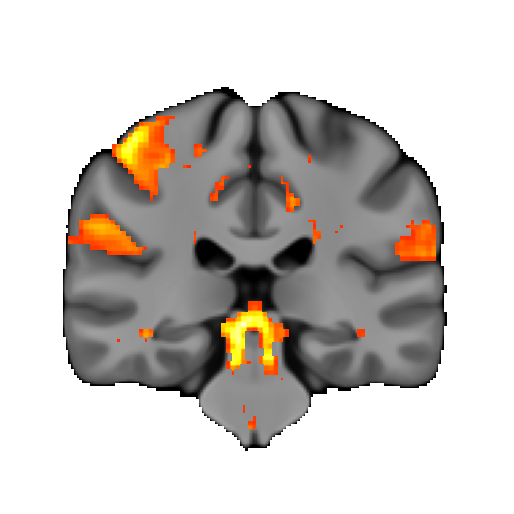

Saved: C:\Users\psiok\Box\3.Projects\3.MDART-Paper\MDART_Analyses\outputs\figures\AJS_probability_suppFig_PAG_y96_tmin6.png


In [7]:
plot_brain_slice_supp(
    t_path        = maps_dir + "/probability_FDR0.005_posOnly.nii.gz",
    template_path = template_path,
    out_path      = os.path.join(out_dir, "AJS_probability_suppFig_PAG_y96_tmin6.png"),
    slice_axis    = "y",
    slice_idx     = 96,   # voxel index in the TEMPLATE (1mm) space
    vlim          = 14,
    t_min         = 6
)

### Risk

Slice: x=83 (template voxel) -> 7.0 mm


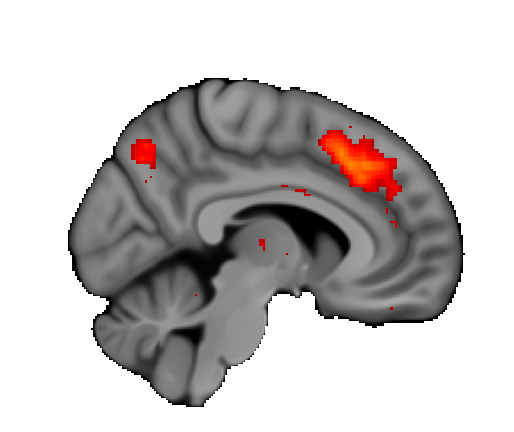

Saved: C:\Users\psiok\Box\3.Projects\3.MDART-Paper\MDART_Analyses\outputs\figures\AJS_risk_suppFig_DlPFC_MCC_x83.png


In [8]:
plot_brain_slice_supp(
    t_path        = maps_dir + "/risk_FDR0.005_posOnly.nii.gz",
    template_path = template_path,
    out_path      = os.path.join(out_dir, "AJS_risk_suppFig_DlPFC_MCC_x83.png"),
    slice_axis    = "x",
    slice_idx     = 83,   # voxel index in the TEMPLATE (1mm) space
    vlim          = 14,
)

### Ambiguity

Slice: y=138 (template voxel) -> 12.0 mm


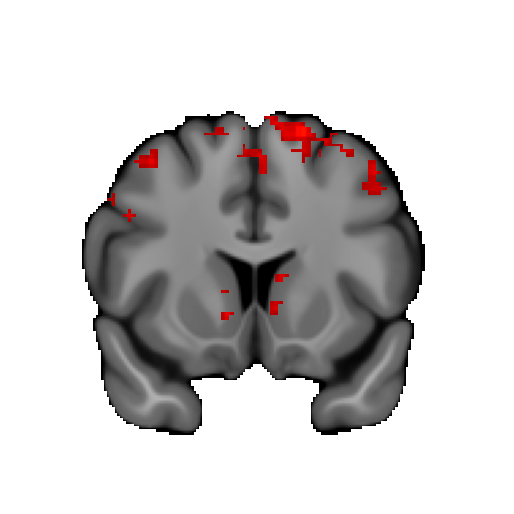

Saved: C:\Users\psiok\Box\3.Projects\3.MDART-Paper\MDART_Analyses\outputs\figures\AJS_ambiguity_y138_Caudate_MFG_OFC_SFG.png


In [9]:
plot_brain_slice_supp(
    t_path        = maps_dir + "/ambiguity_FDR0.005_posOnly.nii.gz",
    template_path = template_path,
    out_path      = os.path.join(out_dir, "AJS_ambiguity_y138_Caudate_MFG_OFC_SFG.png"),
    slice_axis    = "y",
    slice_idx     = 138,   # voxel index in the TEMPLATE (1mm) space
    vlim          = 14,
)

### Certain Threat vs Certain Safe

Slice: x=94 (template voxel) -> -4.0 mm


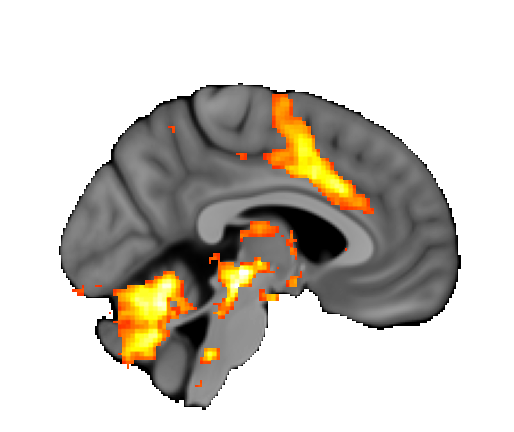

Saved: C:\Users\psiok\Box\3.Projects\3.MDART-Paper\MDART_Analyses\outputs\figures\AJS_CertainThreatvsCertainSafe_x94_MCC_PAG.png


In [10]:
plot_brain_slice_supp(
    t_path        = maps_dir + "/certainThreat_vs_certainSafe_FDR0.005_posOnly.nii.gz",
    template_path = template_path,
    out_path      = os.path.join(out_dir, "AJS_CertainThreatvsCertainSafe_x94_MCC_PAG.png"),
    slice_axis    = "x",
    slice_idx     = 94,   # voxel index in the TEMPLATE (1mm) space
    vlim          = 14,
    t_min         = 6
)

### Uncertain Threat vs. Certain Threat

Slice: y=148 (template voxel) -> 22.0 mm


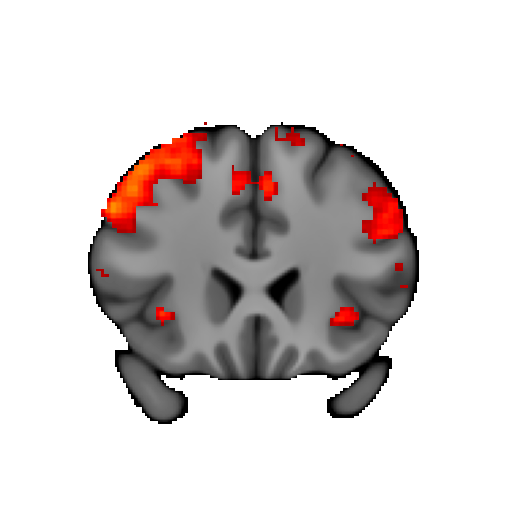

Saved: C:\Users\psiok\Box\3.Projects\3.MDART-Paper\MDART_Analyses\outputs\figures\AJS_UncertainThreatvsCertainThreat_y148_AI_MFG_Paracingulate.png


In [11]:
plot_brain_slice_supp(
    t_path        = maps_dir + "/uncertainThreat_vs_certainThreat_FDR0.005_posOnly.nii.gz",
    template_path = template_path,
    out_path      = os.path.join(out_dir, "AJS_UncertainThreatvsCertainThreat_y148_AI_MFG_Paracingulate.png"),
    slice_axis    = "y",
    slice_idx     = 148,   # voxel index in the TEMPLATE (1mm) space
    vlim          = 14
)

### 50% Threat vs Safe

Slice: x=86 (template voxel) -> 4.0 mm


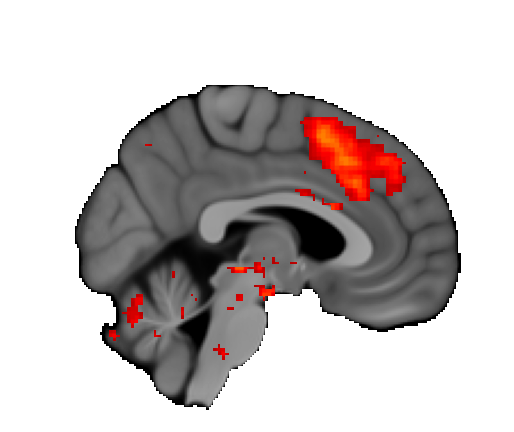

Saved: C:\Users\psiok\Box\3.Projects\3.MDART-Paper\MDART_Analyses\outputs\figures\AJS_50%vsSafe_x86_paracingulate.png


In [12]:
plot_brain_slice_supp(
    t_path        = maps_dir + "/c50vs0_FDR0.005_posOnly.nii.gz",
    template_path = template_path,
    out_path      = os.path.join(out_dir, "AJS_50%vsSafe_x86_paracingulate.png"),
    slice_axis    = "x",
    slice_idx     = 86,   # voxel index in the TEMPLATE (1mm) space
    vlim          = 14
)

#### Plotting the color bar

In [13]:
vlim = 14

fig, ax = plt.subplots(figsize=(0.08, 14/25.4))
norm = Normalize(vmin=-vlim, vmax=vlim)
cb = fig.colorbar(_cm.ScalarMappable(norm=norm, cmap=cold_hot), cax=ax)
cb.set_label(" ", fontsize=5.5, labelpad=0, rotation=270)
#cb.set_ticks([-vlim, vlim])
cb.set_ticks([])
cb.ax.tick_params(pad=0, length=4, width=0, labelsize=5)
cb.outline.set_linewidth(0.2)

#plt.tight_layout()
fig.savefig(os.path.join(out_dir, "colorbar_cold_hot_vlim14.png"), dpi=300, bbox_inches="tight", transparent=True)
plt.show()

#### Color bars matched to positive-only / thresholded slices

In [14]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    """Return a new colormap made of cmap's colors between minval and maxval (0-1 fractions)."""
    return LinearSegmentedColormap.from_list(
        f"{cmap.name}_trunc_{minval:.2f}_{maxval:.2f}",
        cmap(np.linspace(minval, maxval, n)),
    )


def plot_pos_colorbar(
    vlim,
    t_min,
    out_path,
    figsize=(0.08, 14 / 25.4),
    dpi=300,
    show_ticks=False,
):
    """
    Colorbar for a posOnly slice plotted with cold_hot normalized over
    [-vlim, vlim] (matches plot_brain_slice_supp). Reproduces only the
    portion of the colormap that is actually visible in that plot:

        t_min = 0  -> unthresholded positive half (Risk / Ambiguity)
        t_min > 0  -> additionally-thresholded half (Probability)
    """
    frac_low = (t_min - (-vlim)) / (2 * vlim)
    cmap_pos = truncate_colormap(cold_hot, frac_low, 1.0)
    norm = Normalize(vmin=t_min, vmax=vlim)

    fig, ax = plt.subplots(figsize=figsize)
    cb = fig.colorbar(_cm.ScalarMappable(norm=norm, cmap=cmap_pos), cax=ax)

    if show_ticks:
        cb.set_ticks([t_min, vlim])
        cb.ax.tick_params(pad=2, length=4, width=0.4, labelsize=5)
    else:
        cb.set_ticks([])
        cb.ax.tick_params(pad=0, length=4, width=0, labelsize=5)
    cb.outline.set_linewidth(0.2)

    plt.show()
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight", transparent=True)
    plt.close(fig)
    print(f"Saved: {out_path}")

In [15]:
# Probability: FDR<0.005 + posOnly + extra t_min=6 threshold -> colorbar covers 6..14
plot_pos_colorbar(
    vlim=14,
    t_min=6,
    out_path=os.path.join(out_dir, "colorbar_probability_tmin6_vlim14.png"),
)

# Risk & Ambiguity: FDR<0.005 + posOnly, no extra threshold -> shared colorbar covers 0..14
plot_pos_colorbar(
    vlim=14,
    t_min=0,
    out_path=os.path.join(out_dir, "colorbar_risk_ambiguity_vlim14.png"),
)

Saved: C:\Users\psiok\Box\3.Projects\3.MDART-Paper\MDART_Analyses\outputs\figures\colorbar_probability_tmin6_vlim14.png


Saved: C:\Users\psiok\Box\3.Projects\3.MDART-Paper\MDART_Analyses\outputs\figures\colorbar_risk_ambiguity_vlim14.png
